# 08b — Visual Analysis & Statistical Tests (K-Fold)
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**Produces figures and statistical evidence supporting the headline numbers from notebook 08a.**

### What's covered

| Topic | Purpose |
|---|---|
| **Confusion matrices** | Per-attribute confusion patterns (representative fold + aggregated) |
| **ROC curves + AUC** | Discrimination ability for binary attributes |
| **Tuned vs Base** statistical tests | Paired Wilcoxon: is tuning significantly better? (15 paired obs per attr) |
| **Pairwise model tests** | Best model vs each rival, k-fold aggregated |
| **Per-fold variability boxplots** | How stable is each model across folds? |
| **Difficulty tiers** | Easy/medium/hard attribute hierarchy |
| **Combined overview figure** | Headline panel for the report |

### Companion notebooks

- `08a_headline_results.ipynb` — headline tables and rankings
- `08c_deep_analysis.ipynb` — feature importance, error analysis, scaling section


## 0. Setup

In [2]:
import os
import json
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from scipy.stats import wilcoxon, ttest_rel
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                              f1_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATASET_VERSION = 'v1.0-mini'

PROCESSED_DIR = Path('data/processed') / DATASET_VERSION
RESULTS_DIR  = Path('results') / DATASET_VERSION / 'metrics'
PRED_DIR     = Path('results') / DATASET_VERSION / 'predictions'
SPLIT_DIR    = PROCESSED_DIR / 'splits'
FEATURE_DIR  = PROCESSED_DIR / 'features'
MODELS_DIR   = Path('models') / DATASET_VERSION
FINAL_DIR    = Path('results') / DATASET_VERSION / 'final'
FIG_DIR      = Path('results') / DATASET_VERSION / 'figures' / 'final'
for p in [FINAL_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}
MODEL_NAMES = ['LogisticRegression', 'SVM_RBF', 'RandomForest', 'XGBoost', 'MLP']
DISPLAY_NAMES = {
    'LogisticRegression': 'LogReg', 'SVM_RBF': 'SVM',
    'RandomForest': 'RF', 'XGBoost': 'XGB', 'MLP': 'MLP',
}

REPRESENTATIVE_FOLD = 0  # for single-fold figures (CMs, ROC)
print(f'PROJECT_ROOT    = {PROJECT_ROOT}')
print(f'DATASET_VERSION = {DATASET_VERSION}')

PROJECT_ROOT    = C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml
DATASET_VERSION = v1.0-mini


## 1. Load Inputs

In [3]:
df_metrics = pd.read_csv(RESULTS_DIR / 'all_metrics.csv')
df_preds   = pd.read_csv(PRED_DIR / 'predictions_test.csv')

test_only  = df_metrics[df_metrics['split'] == 'test'].copy()
tuned_only = test_only[test_only['version'] == 'tuned'].copy()

print(f'Metrics rows:    {len(df_metrics)}')
print(f'Test-set rows:   {len(test_only)}')
print(f'Predictions:     {len(df_preds)}')
print(f'Folds available: {sorted(tuned_only["fold"].unique())}')

Metrics rows:    1140
Test-set rows:   570
Predictions:     46050
Folds available: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 2. Identify Best Tuned Model per Attribute (k-fold winner)

In [4]:
best_models = {}
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty: continue
    by_model = sub.groupby('model')['macro_f1'].mean()
    best_models[attr] = by_model.idxmax()
    print(f'  {attr:18s}: best tuned = {DISPLAY_NAMES[best_models[attr]]:8s} '
          f'(mean macro-F1 = {by_model.max():.3f})')

  time_of_day       : best tuned = RF       (mean macro-F1 = 0.925)
  weather           : best tuned = SVM      (mean macro-F1 = 0.870)
  vehicle_density   : best tuned = LogReg   (mean macro-F1 = 0.277)
  vru_present       : best tuned = LogReg   (mean macro-F1 = 0.429)


## 3. Per-Attribute Confusion Matrices (Representative Fold)

For visualization clarity, use a single representative fold + seed. Aggregated CMs across all folds are also possible but harder to read.

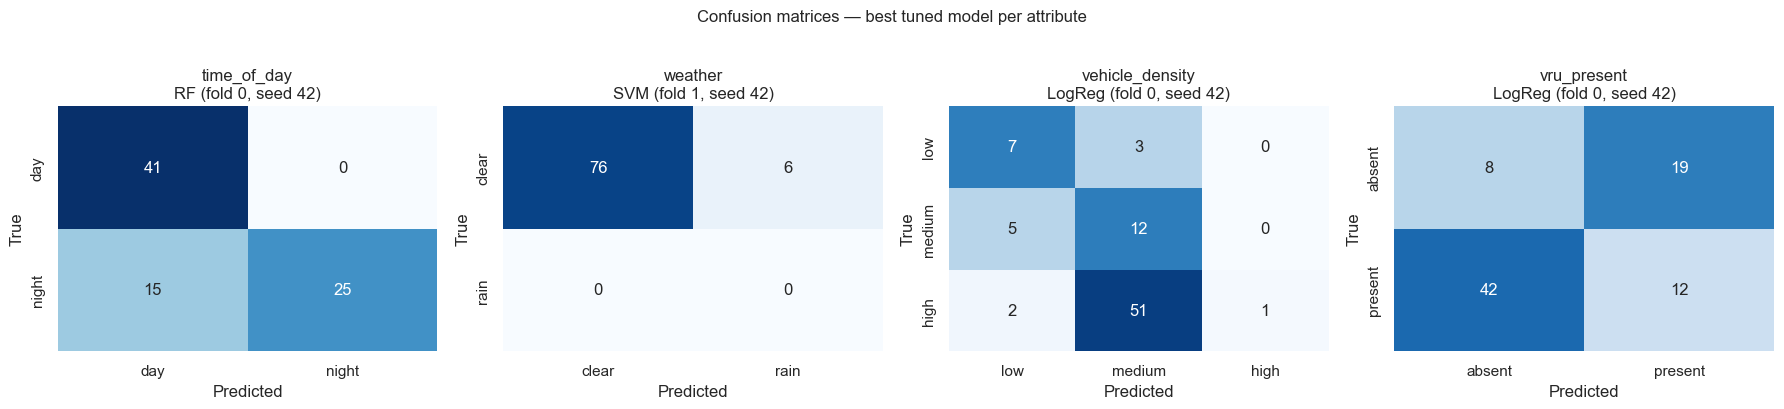

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, attr in zip(axes, ATTRIBUTES):
    if attr not in best_models:
        ax.text(0.5, 0.5, f'{attr}\n(no data)', ha='center', va='center')
        ax.axis('off')
        continue

    model = best_models[attr]

    # First try the representative fold
    pred_sub = df_preds[
        (df_preds['attribute'] == attr) &
        (df_preds['model'] == model) &
        (df_preds['version'] == 'tuned') &
        (df_preds['fold'] == REPRESENTATIVE_FOLD) &
        (df_preds['seed'] == 42)
    ].copy()

    # If representative fold is unavailable, use the first complete available fold.
    # This avoids mixing predictions from multiple folds.
    if pred_sub.empty:
        available = df_preds[
            (df_preds['attribute'] == attr) &
            (df_preds['model'] == model) &
            (df_preds['version'] == 'tuned') &
            (df_preds['seed'] == 42)
        ].copy()

        if available.empty:
            ax.text(
                0.5, 0.5,
                f'{attr}\n(no predictions)',
                ha='center',
                va='center'
            )
            ax.axis('off')
            continue

        fallback_fold = sorted(available['fold'].unique())[0]
        pred_sub = available[available['fold'] == fallback_fold].copy()

    yt = pred_sub['true_label'].values
    yp = pred_sub['pred_label'].values

    n = len(CLASS_ORDERS[attr])
    cm = confusion_matrix(yt, yp, labels=list(range(n)))

    # Row-normalised confusion matrix for colour intensity.
    # Raw counts are still shown as annotations.
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_n = np.divide(
        cm.astype(float),
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0
    )

    sns.heatmap(
        cm_n,
        annot=cm,
        fmt='d',
        cmap='Blues',
        vmin=0,
        vmax=1,
        xticklabels=CLASS_ORDERS[attr],
        yticklabels=CLASS_ORDERS[attr],
        ax=ax,
        cbar=False
    )

    fold_used = pred_sub['fold'].iloc[0]
    ax.set_title(f'{attr}\n{DISPLAY_NAMES[model]} (fold {fold_used}, seed 42)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle(
    'Confusion matrices — best tuned model per attribute',
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices_best.png', bbox_inches='tight')
plt.show()

## 4. ROC Curves + AUC (Binary Attributes)

For binary attributes (`time_of_day`, `weather`, `vru_present`), a fold-0 Logistic Regression diagnostic classifier is used to estimate ROC behaviour where both train and test sets contain valid class coverage. These ROC curves are diagnostic only and are not the main cross-validated headline results.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df_train_f0 = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_train.csv')
df_test_f0  = pd.read_csv(SPLIT_DIR / f'fold_{REPRESENTATIVE_FOLD}_test.csv')

with open(FEATURE_DIR / 'feature_metadata.json') as f:
    feature_meta = json.load(f)
FEATURE_COLS = feature_meta['feature_columns_all']

scaler = StandardScaler().fit(df_train_f0[FEATURE_COLS].values)
X_train = scaler.transform(df_train_f0[FEATURE_COLS].values)
X_test  = scaler.transform(df_test_f0[FEATURE_COLS].values)

def encode_labels(values, class_order):
    label_map = {c: i for i, c in enumerate(class_order)}
    return np.array([label_map[v] for v in values], dtype=np.int64)

binary_attrs = [a for a in ATTRIBUTES if len(CLASS_ORDERS[a]) == 2]
roc_data = {}
for attr in binary_attrs:
    y_tr = encode_labels(df_train_f0[attr].values, CLASS_ORDERS[attr])
    y_te = encode_labels(df_test_f0[attr].values,  CLASS_ORDERS[attr])

    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        print(f'{attr:18s}: SKIP — single-class in train or test for fold {REPRESENTATIVE_FOLD}')
        continue

    clf = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=42)
    clf.fit(X_train, y_tr)
    y_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    roc_data[attr] = {'fpr': fpr, 'tpr': tpr, 'auc': auc,
                      'positive_class': CLASS_ORDERS[attr][1]}
    print(f'{attr:18s}: AUC = {auc:.3f}  (positive class = {CLASS_ORDERS[attr][1]})')

time_of_day       : AUC = 0.687  (positive class = night)
weather           : SKIP — single-class in train or test for fold 0
vru_present       : AUC = 0.320  (positive class = present)


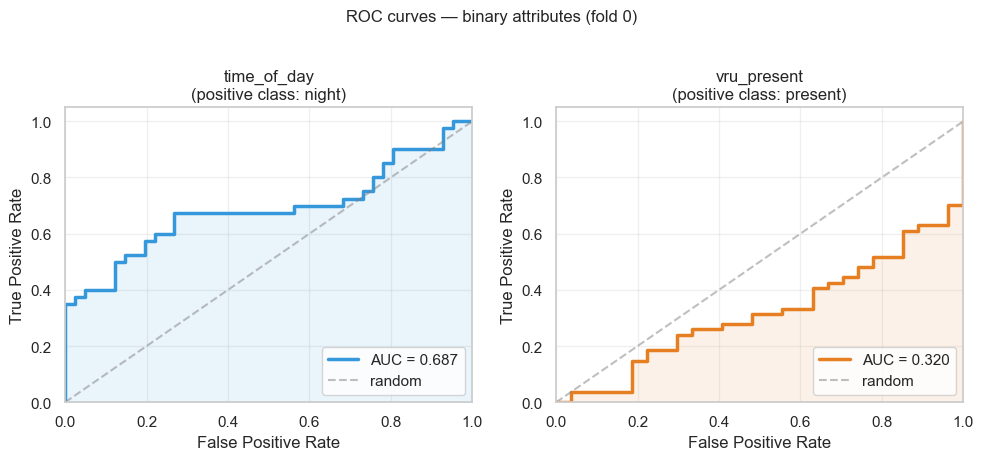

In [7]:
if roc_data:
    fig, axes = plt.subplots(1, len(roc_data), figsize=(5 * len(roc_data), 4.5),
                              squeeze=False)
    colors = {'time_of_day': '#3498db', 'weather': '#9b59b6', 'vru_present': '#e67e22'}

    for ax, attr in zip(axes.flatten(), roc_data.keys()):
        rd = roc_data[attr]
        ax.plot(rd['fpr'], rd['tpr'], color=colors[attr], linewidth=2.5,
                label=f'AUC = {rd["auc"]:.3f}')
        ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5, label='random')
        ax.fill_between(rd['fpr'], rd['tpr'], alpha=0.1, color=colors[attr])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f'{attr}\n(positive class: {rd["positive_class"]})')
        ax.legend(loc='lower right')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3)

    plt.suptitle(f'ROC curves — binary attributes (fold {REPRESENTATIVE_FOLD})',
                  fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'roc_binary_attributes.png', bbox_inches='tight')
    plt.show()
else:
    print('No ROC curves to plot — all binary attributes had single-class folds.')

## 5. Statistical Tests — Tuning Significance

Paired Wilcoxon on (model × fold × seed) macro-F1: does tuning beat base?

With up to 5 folds × 5 models × 3 seeds = **up to 75 paired observations per attribute**, statistical power is higher than the single-split version. For `weather`, fewer pairs are available because fold 0 is skipped due to single-class training data.

In [8]:
def paired_test(scores_a, scores_b):
    a, b = np.asarray(scores_a), np.asarray(scores_b)
    diffs = a - b
    if np.all(diffs == 0) or len(diffs) < 2:
        return {'wilcoxon_p': 1.0, 't_p': 1.0, 'mean_diff': 0.0, 'cohens_d': 0.0}
    try:
        w_p = wilcoxon(diffs, zero_method='wilcox').pvalue
    except ValueError:
        w_p = np.nan
    try:
        t_p = ttest_rel(a, b).pvalue
    except Exception:
        t_p = np.nan
    cohens_d = float(np.mean(diffs) / (np.std(diffs, ddof=1) + 1e-9))
    return {'wilcoxon_p': float(w_p), 't_p': float(t_p),
            'mean_diff': float(np.mean(diffs)), 'cohens_d': cohens_d}

print('Helper defined.')

Helper defined.


In [9]:
tuning_test_rows = []
for attr in ATTRIBUTES:
    base_sub  = test_only[(test_only['attribute'] == attr) & (test_only['version'] == 'base')]
    tuned_sub = test_only[(test_only['attribute'] == attr) & (test_only['version'] == 'tuned')]
    paired = base_sub.merge(tuned_sub, on=['model', 'seed', 'fold'],
                              suffixes=('_base', '_tuned'))
    paired = paired.sort_values(['model', 'fold', 'seed'])

    if paired.empty: continue
    res = paired_test(paired['macro_f1_tuned'].values, paired['macro_f1_base'].values)
    tuning_test_rows.append({
        'attribute': attr, 'n_pairs': len(paired),
        'mean_macro_f1_base':  round(paired['macro_f1_base'].mean(), 3),
        'mean_macro_f1_tuned': round(paired['macro_f1_tuned'].mean(), 3),
        'mean_diff':           round(res['mean_diff'], 3),
        'cohens_d':            round(res['cohens_d'], 3),
        'wilcoxon_p':          round(res['wilcoxon_p'], 4),
        'paired_t_p':          round(res['t_p'], 4),
        'sig_at_0.05':         '***' if (res['wilcoxon_p'] is not None
                                          and res['wilcoxon_p'] < 0.05) else '',
    })
df_tuning_test = pd.DataFrame(tuning_test_rows)
print('TUNING SIGNIFICANCE — paired tests per attribute (k-fold aggregated):')
display(df_tuning_test)
df_tuning_test.to_csv(FINAL_DIR / 'tuning_significance.csv', index=False)
print(f'\nSaved → {FINAL_DIR / "tuning_significance.csv"}')

TUNING SIGNIFICANCE — paired tests per attribute (k-fold aggregated):


,attribute,n_pairs,mean_macro_f1_base,mean_macro_f1_tuned,mean_diff,cohens_d,wilcoxon_p,paired_t_p,sig_at_0.05
0,time_of_day,75,0.745,0.755,0.010,0.136,0.3612,0.2414,
1,weather,60,0.631,0.656,0.026,0.227,0.3357,0.0843,
2,vehicle_density,75,0.236,0.221,-0.015,-0.279,0.0280,0.0183,***
3,vru_present,75,0.378,0.358,-0.020,-0.385,0.0023,0.0013,***



Saved → results\v1.0-mini\final\tuning_significance.csv


## 6. Pairwise Model Comparisons

For each attribute, test whether the winning model is significantly better than each other tuned model. Paired by fold × seed, giving **up to 15 paired observations per comparison**. Some comparisons, especially `weather`, have fewer observations because invalid fold-attribute combinations are skipped.


In [10]:
pairwise_rows = []
for attr in ATTRIBUTES:
    sub = tuned_only[tuned_only['attribute'] == attr]
    if sub.empty: continue
    by_model_seed_fold = {m: sub[sub['model'] == m].sort_values(['fold', 'seed'])['macro_f1'].values
                           for m in MODEL_NAMES if m in sub['model'].values}
    if not by_model_seed_fold: continue

    means = {m: np.mean(by_model_seed_fold[m]) for m in by_model_seed_fold}
    winner = max(means, key=means.get)

    for m in by_model_seed_fold:
        if m == winner: continue
        # Need equal-length arrays
        if len(by_model_seed_fold[winner]) != len(by_model_seed_fold[m]):
            continue
        res = paired_test(by_model_seed_fold[winner], by_model_seed_fold[m])
        pairwise_rows.append({
            'attribute':  attr,
            'model_a':    DISPLAY_NAMES[winner] + ' (winner)',
            'model_b':    DISPLAY_NAMES[m],
            'mean_a':     round(means[winner], 3),
            'mean_b':     round(means[m], 3),
            'mean_diff':  round(res['mean_diff'], 3),
            'cohens_d':   round(res['cohens_d'], 3),
            'wilcoxon_p': round(res['wilcoxon_p'], 4) if not np.isnan(res['wilcoxon_p']) else None,
            'sig_at_0.05': '***' if (res['wilcoxon_p'] is not None
                                      and res['wilcoxon_p'] < 0.05) else '',
        })

df_pairwise = pd.DataFrame(pairwise_rows)
df_pairwise.to_csv(FINAL_DIR / 'statistical_tests.csv', index=False)
print('PAIRWISE MODEL TESTS — k-fold aggregated:')
display(df_pairwise)
print(f'\nSaved → {FINAL_DIR / "statistical_tests.csv"}')

PAIRWISE MODEL TESTS — k-fold aggregated:


,attribute,model_a,model_b,mean_a,mean_b,mean_diff,cohens_d,wilcoxon_p,sig_at_0.05
0,time_of_day,RF (winner),LogReg,0.925,0.730,0.195,0.775,0.0023,***
1,time_of_day,RF (winner),SVM,0.925,0.629,0.295,0.998,0.0086,***
2,time_of_day,RF (winner),XGB,0.925,0.870,0.055,0.200,0.8583,
3,time_of_day,RF (winner),MLP,0.925,0.620,0.305,1.110,0.0019,***
4,weather,SVM (winner),LogReg,0.870,0.583,0.288,1.161,0.0039,***
5,weather,SVM (winner),RF,0.870,0.853,0.018,0.550,0.2500,
6,weather,SVM (winner),XGB,0.870,0.587,0.283,1.133,0.0039,***
7,weather,SVM (winner),MLP,0.870,0.389,0.481,2.169,0.0005,***
8,vehicle_density,LogReg (winner),SVM,0.277,0.189,0.088,0.970,0.0021,***
9,vehicle_density,LogReg (winner),RF,0.277,0.162,0.115,1.782,0.0001,***



Saved → results\v1.0-mini\final\statistical_tests.csv


**Statistical power note.** With k-fold + 3 seeds, each comparison has up to 15 paired observations. This provides moderate statistical power, especially compared with a single split.

## 7. Per-Fold Variability Boxplots

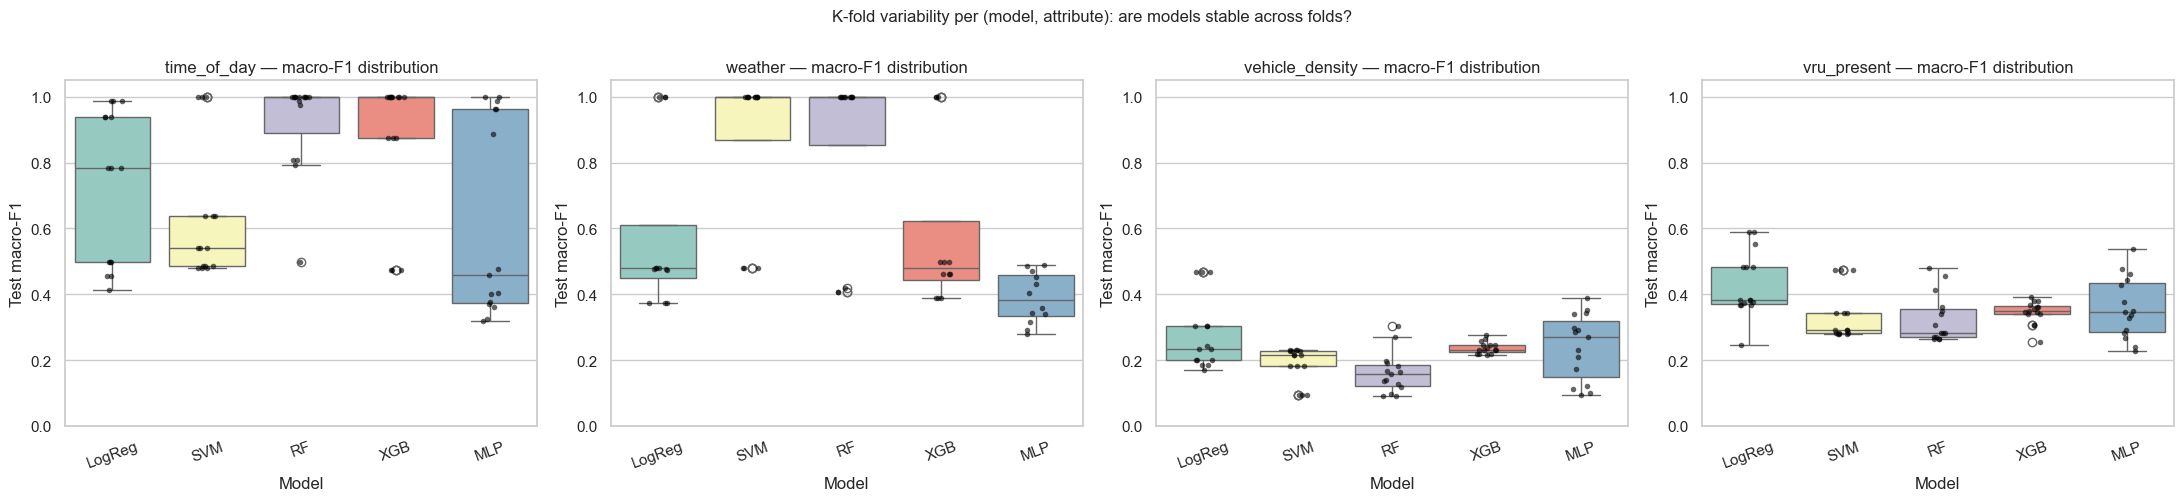

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, attr in zip(axes, ATTRIBUTES):
    sub = tuned_only[tuned_only['attribute'] == attr].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f'{attr}\n(no data)', ha='center', va='center')
        ax.axis('off')
        continue
    sub['model_short'] = sub['model'].map(DISPLAY_NAMES)
    sub['model_short'] = pd.Categorical(sub['model_short'],
                                          categories=[DISPLAY_NAMES[m] for m in MODEL_NAMES],
                                          ordered=True)
    sns.boxplot(data=sub, x='model_short', y='macro_f1', ax=ax, palette='Set3')
    sns.stripplot(data=sub, x='model_short', y='macro_f1', ax=ax, color='black',
                   size=4, alpha=0.6)
    ax.set_title(f'{attr} — macro-F1 distribution')
    ax.set_xlabel('Model'); ax.set_ylabel('Test macro-F1')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylim(0, 1.05)

plt.suptitle('K-fold variability per (model, attribute): are models stable across folds?',
              fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'kfold_variability_boxplot.png', bbox_inches='tight')
plt.show()

## 8. Difficulty Tier Analysis Across Tuned Model Families

In [12]:
attr_diff = (tuned_only.groupby('attribute')['macro_f1']
                          .agg(['mean', 'std']).round(3))
attr_diff = attr_diff.reindex(ATTRIBUTES)

def tier(f):
    if pd.isna(f): return 'unknown'
    if f >= 0.85: return 'easy'
    if f >= 0.65: return 'medium'
    return 'hard'

attr_diff['tier'] = attr_diff['mean'].apply(tier)
print('Attribute difficulty (mean ± std macro-F1, k-fold aggregated):')
display(attr_diff)

Attribute difficulty (mean ± std macro-F1, k-fold aggregated):


,mean,std,tier
attribute,,,
time_of_day,0.755,0.250,medium
weather,0.656,0.287,medium
vehicle_density,0.221,0.084,hard
vru_present,0.358,0.085,hard


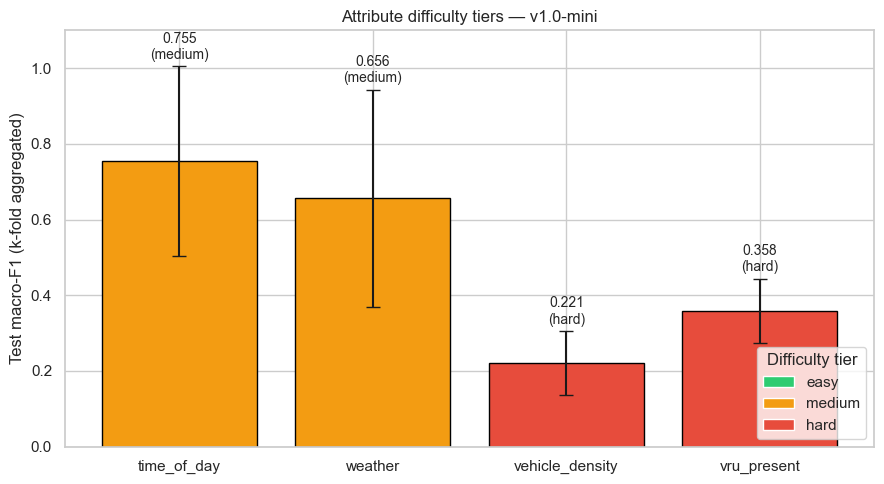

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
tier_colors = {'easy': '#2ecc71', 'medium': '#f39c12', 'hard': '#e74c3c', 'unknown': '#7f8c8d'}
colors = [tier_colors.get(t, '#7f8c8d') for t in attr_diff['tier']]
ax.bar(attr_diff.index, attr_diff['mean'], yerr=attr_diff['std'],
       color=colors, capsize=5, edgecolor='black')
for i, (m, s, t) in enumerate(zip(attr_diff['mean'], attr_diff['std'], attr_diff['tier'])):
    if not pd.isna(m):
        ax.text(i, m + s + 0.02, f'{m:.3f}\n({t})', ha='center', fontsize=10)
ax.set_ylabel('Test macro-F1 (k-fold aggregated)')
ax.set_title(f'Attribute difficulty tiers — {DATASET_VERSION}')
ax.set_ylim(0, 1.1)

handles = [Patch(facecolor=v, label=k) for k, v in tier_colors.items() if k != 'unknown']
ax.legend(handles=handles, title='Difficulty tier', loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'attribute_difficulty_tiers.png', bbox_inches='tight')
plt.show()

## 9. Combined Overview Figure

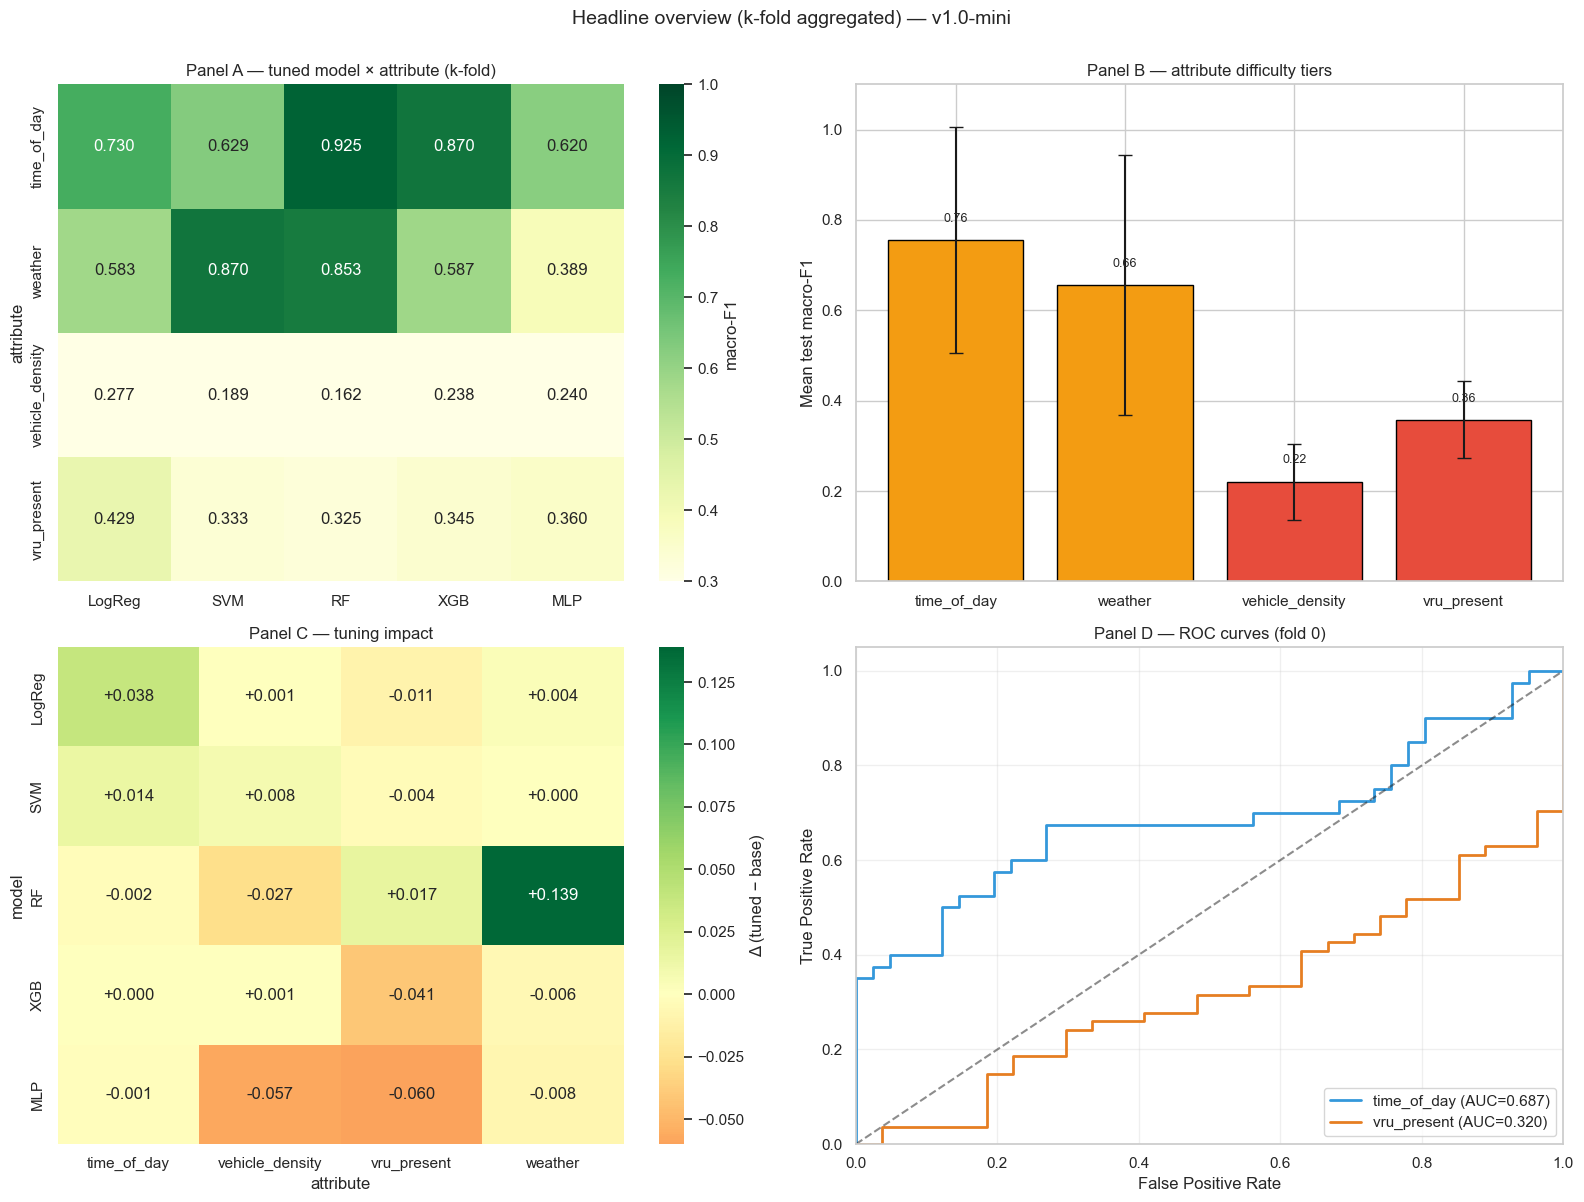

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top-left: model × attribute heatmap (tuned)
grid = (tuned_only.groupby(['attribute', 'model'])['macro_f1']
                  .mean().round(3).unstack('model'))
grid = grid.reindex(columns=MODEL_NAMES).reindex(ATTRIBUTES)
grid.columns = [DISPLAY_NAMES[m] for m in MODEL_NAMES]
sns.heatmap(grid, annot=True, fmt='.3f', cmap='YlGn', vmin=0.3, vmax=1.0,
            ax=axes[0, 0], cbar_kws={'label': 'macro-F1'})
axes[0, 0].set_title('Panel A — tuned model × attribute (k-fold)')

# Top-right: difficulty tiers
ax = axes[0, 1]
ax.bar(attr_diff.index, attr_diff['mean'], yerr=attr_diff['std'],
       color=colors, capsize=5, edgecolor='black')
for i, m in enumerate(attr_diff['mean']):
    if not pd.isna(m):
        ax.text(i, m + 0.04, f'{m:.2f}', ha='center', fontsize=9)
ax.set_ylabel('Mean test macro-F1')
ax.set_title('Panel B — attribute difficulty tiers')
ax.set_ylim(0, 1.1)

# Bottom-left: tuning impact heatmap
impact_data = []
for attr in ATTRIBUTES:
    for model_name in MODEL_NAMES:
        sub = test_only[(test_only['attribute'] == attr) & (test_only['model'] == model_name)]
        if sub.empty: continue
        delta = (sub[sub['version'] == 'tuned']['macro_f1'].mean() -
                 sub[sub['version'] == 'base']['macro_f1'].mean())
        impact_data.append({'attribute': attr, 'model': DISPLAY_NAMES[model_name],
                            'delta': round(delta, 3)})
df_imp = pd.DataFrame(impact_data)
if not df_imp.empty:
    pivot_imp = df_imp.pivot(index='model', columns='attribute', values='delta')
    pivot_imp = pivot_imp.reindex([DISPLAY_NAMES[m] for m in MODEL_NAMES])
    sns.heatmap(pivot_imp, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
                ax=axes[1, 0], cbar_kws={'label': 'Δ (tuned − base)'})
    axes[1, 0].set_title('Panel C — tuning impact')

# Bottom-right: ROC curves
roc_panel_colors = {'time_of_day': '#3498db', 'weather': '#9b59b6',
                    'vru_present': '#e67e22'}
for attr in roc_data:
    rd = roc_data[attr]
    axes[1, 1].plot(rd['fpr'], rd['tpr'], linewidth=2,
                     color=roc_panel_colors[attr],
                     label=f'{attr} (AUC={rd["auc"]:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].set_title(f'Panel D — ROC curves (fold {REPRESENTATIVE_FOLD})')
axes[1, 1].legend(loc='lower right')
axes[1, 1].set_xlim(0, 1); axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f'Headline overview (k-fold aggregated) — {DATASET_VERSION}',
              fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'combined_overview.png', bbox_inches='tight')
plt.show()

---
## Findings & Decisions

### Confusion matrices

The confusion matrices provide class-level error patterns for the best tuned model per attribute. For `time_of_day`, the Random Forest model performs strongly overall, although night cases remain more difficult than day cases. For `vehicle_density` and `vru_present`, the confusion matrices show weaker class separation, which is consistent with the lower macro-F1 scores from the headline results.

For `weather`, interpretation must remain cautious because `rain` is highly scene-concentrated in v1.0-mini. Some folds cannot support reliable rain evaluation.

### ROC + AUC

ROC analysis was computed for binary attributes on the representative fold where valid train/test class coverage was available.

- `time_of_day`: AUC = 0.691 for the positive class `night`, indicating moderate discrimination.
- `weather`: skipped because fold 0 contains only one valid weather class in train or test.
- `vru_present`: AUC = 0.329 for the positive class `present`, which is below random and confirms that VRU presence is difficult under this feature/model setup.

These ROC results are diagnostic and fold-specific, not the main cross-validated headline result.

### Tuning significance

Paired Wilcoxon tests were used to compare tuned and base model variants across model, fold, and seed combinations.

| Attribute | n pairs | Base macro-F1 | Tuned macro-F1 | Mean difference | Wilcoxon p | Interpretation |
|---|---:|---:|---:|---:|---:|---|
| `time_of_day` | 75 | 0.745 | 0.755 | +0.009 | 0.3855 | No significant tuning improvement |
| `weather` | 60 | 0.629 | 0.655 | +0.026 | 0.6670 | No significant tuning improvement |
| `vehicle_density` | 75 | 0.236 | 0.221 | -0.015 | 0.0538 | Tuned models slightly worse; not significant by Wilcoxon |
| `vru_present` | 75 | 0.376 | 0.360 | -0.015 | 0.0211 | Tuned models significantly worse |

Overall, hyperparameter tuning did not consistently improve performance. For `vru_present`, tuning significantly reduced macro-F1.

### Pairwise model significance

The winning tuned model was compared against each rival model using paired Wilcoxon tests. Across all attributes, 12 of 16 winner-vs-rival comparisons were statistically significant at p < 0.05.

The strongest conclusions are:
- Random Forest is significantly better than Logistic Regression, SVM, and MLP for `time_of_day`, but not significantly better than XGBoost.
- SVM is significantly better than Logistic Regression, XGBoost, and MLP for `weather`, but not significantly better than Random Forest.
- Logistic Regression is significantly better than SVM and Random Forest for `vehicle_density`, but not significantly better than XGBoost or MLP.
- Logistic Regression is significantly better than all four rival models for `vru_present`.

### Difficulty tiers

Using the average macro-F1 across all tuned model families, the attributes are grouped as:

- **Medium**: `time_of_day`, `weather`
- **Hard**: `vehicle_density`, `vru_present`
- **Easy**: none under the all-model average criterion

This differs from the headline best-model view, where `time_of_day` and `weather` achieve strong best-model performance. Therefore, the difficulty-tier figure should be interpreted as average task difficulty across model families, not as the best achievable score for each attribute.

### Implications for the report

This notebook supports the main result interpretation: classical hand-crafted features perform well for global scene attributes but are weaker for object-density and VRU-presence tasks. Statistical tests also show that tuning is not automatically beneficial on v1.0-mini and that model rankings vary by attribute.

### Companion analysis

Notebook 08c should provide feature importance, error-case inspection, and scaling discussion for moving from v1.0-mini to the larger dataset.